In [1]:
from pyspark.sql import SparkSession
import os
import pyspark.sql.functions as sf

In [2]:
# Get the access and secret keys to connect to s3
access_key = os.getenv("S3_ACCESS_KEY")
secret_key = os.getenv("S3_SECRET_KEY") 

# Create a spark session including modules to connect to s3
# Added the third line in which I can set manually the memory usage for each worker
spark = SparkSession.builder \
    .master("spark://master:7077")\
    .appName("Anomaly Detection")\
    .config('spark.jars.packages', 'org.apache.hadoop:hadoop-aws:3.4.1,org.apache.hadoop:hadoop-common:3.4.1')\
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")\
    .config("spark.sql.execution.arrow.pyspark.fallback.enabled", "false")\
    .config('spark.hadoop.fs.s3a.aws.credentials.proviAnvoder', 'org.apache.hadoop.fs.s3a.SimpleAWSCredentialsProvider')\
    .config('spark.hadoop.fs.s3a.access.key', access_key)\
    .config('spark.hadoop.fs.s3a.secret.key', secret_key)\
    .config('spark.hadoop.fs.s3a.endpoint', 'https://cloud-areapd.pd.infn.it:5210')\
    .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem") \
    .config("spark.hadoop.fs.s3a.metadatastore.impl", "org.apache.hadoop.fs.s3a.s3guard.NullMetadataStore") \
    .config("spark.hadoop.fs.s3a.path.style.access", "true") \
    .config("spark.hadoop.fs.s3a.connection.ssl.enabled","false") \
    .config("com.amazonaws.sdk.disableCertChecking","true") \
    .getOrCreate()

:: loading settings :: url = jar:file:/usr/local/spark/jars/ivy-2.5.3.jar!/org/apache/ivy/core/settings/ivysettings.xml
Ivy Default Cache set to: /home/ubuntu/.ivy2.5.2/cache
The jars for the packages stored in: /home/ubuntu/.ivy2.5.2/jars
org.apache.hadoop#hadoop-aws added as a dependency
org.apache.hadoop#hadoop-common added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-1ea2d56a-7fa4-4de8-8a7f-9b0faed6b8a2;1.0
	confs: [default]
	found org.apache.hadoop#hadoop-aws;3.4.1 in central
	found software.amazon.awssdk#bundle;2.24.6 in central
	found org.wildfly.openssl#wildfly-openssl;1.1.3.Final in central
	found org.apache.hadoop#hadoop-common;3.4.1 in central
	found org.apache.hadoop.thirdparty#hadoop-shaded-protobuf_3_25;1.3.0 in central
	found org.apache.hadoop#hadoop-annotations;3.4.1 in central
	found org.apache.hadoop.thirdparty#hadoop-shaded-guava;1.3.0 in central
	found com.google.guava#guava;27.0-jre in central
	found com.google.guava#failureacce

## **Anomaly detection 1**

## Reads the storage and adjust the dataframe structure

In [3]:
# Read data from the CloudVeneto "bucket" through s3
df_spark = spark.read.parquet("s3a://MAPDB-Group5/data_parquet").orderBy("when")
#df_spark.show(10)

In [4]:
# Overwrite the "when" column, representing a UNIX timestamp, casting that to the native "TimestampType"
# using the native spark function
df_spark = df_spark.withColumn(
    "when",
    sf.timestamp_millis(df_spark.when)
)

# Now let's add a "timestamp_bucket" column, "truncating" everything to the minutes
# to get the same sampling frequency for all data
df_spark = df_spark.withColumn(
    "timestamp_bucket",
    sf.date_trunc("minute", "when")
)

df_spark.printSchema()

root
 |-- when: timestamp (nullable = true)
 |-- hwid: string (nullable = true)
 |-- metric: string (nullable = true)
 |-- value: integer (nullable = true)
 |-- timestamp_bucket: timestamp (nullable = true)



In [5]:
# List of all the metrics that should be aggregated using their mean
continuous_metrics = [
    'E1', 'E2',
    'S19', 'S37', 'S39', 'S40', 'S41', 'S42', 'S43', 'S45', 'S46', 'S47', 'S49', 'S50',
    'S69', 'S70', 'S71', 'S72', 'S80', 'S81', 'S83', 'S86', 'S90', 'S94', 'S97',
    'S100', 'S101', 'S102', 'S106', 'S107', 'S108', 'S109', 'S110',
    'S122', 'S124', 'S125', 'S126', 'S128', 'S129',
    'S137', 'S138', 'S140', 'S143', 'S147',
    'S151', 'S154', 'S157', 'S158', 'S159',
    'S163', 'S164', 'S165', 'S166', 'S167',
    'S178', 'S180', 'S181'
]

# It's important to also groupBy "hwid" which indicates the specific device.
# We use the "coalesce" function because if the metric isn't in the "continuous_metrics" list
# the first expression will implicitly return "null".
# Coalesce returns the first not null value, so if the metric isn't in that list, it will
# automatically pass to the second value and return the max
df_aggregated = (
    df_spark.groupBy("timestamp_bucket", "hwid", "metric")
      .agg(
          sf.coalesce(
              sf.mean(sf.when(sf.col("metric").isin(continuous_metrics), sf.col("value"))),
              sf.max(sf.col("value"))
          ).alias("aggregated_value")
      )
)

#df_aggregated.show(10)
df_aggregated.printSchema()

root
 |-- timestamp_bucket: timestamp (nullable = true)
 |-- hwid: string (nullable = true)
 |-- metric: string (nullable = true)
 |-- aggregated_value: double (nullable = true)



## First part of anomaly detection 1

In [6]:
# I select only the variables needed for this task

target_metrics = ["S117", "S118", "S169", "S170"]
df_anomaly1 = df_aggregated.where(df_aggregated.metric.isin(target_metrics))

In [7]:
import pyspark.sql.functions as F
from pyspark.sql.functions import col, date_trunc
from pyspark.sql.types import IntegerType

df_anomaly1 = df_anomaly1.withColumn(
    "hour_bucket", 
    date_trunc("hour", col("timestamp_bucket"))
)

df_anomaly1.printSchema()

root
 |-- timestamp_bucket: timestamp (nullable = true)
 |-- hwid: string (nullable = true)
 |-- metric: string (nullable = true)
 |-- aggregated_value: double (nullable = true)
 |-- hour_bucket: timestamp (nullable = true)



In [8]:
# 1. Group by the hour, device, and metric to break the data into tiny chunks
# We collect the timestamp and value into a mini-table (struct) inside a list
df_grouped = df_anomaly1.groupBy("hour_bucket", "hwid", "metric").agg(
    F.collect_list(
        F.struct("timestamp_bucket", "aggregated_value")
    ).alias("time_series")
)

# 2. Sort the 60-minute array chronologically (this happens instantly in memory)
df_sorted = df_grouped.withColumn(
    "time_series_sorted", 
    F.array_sort("time_series")
)

# 3. Create a simple Python function (UDF) to count the switches in that small list
def count_switches(time_series):
    if not time_series or len(time_series) < 2:
        return 0
    switches = 0
    # Iterate through the minutes in the hour
    for i in range(1, len(time_series)):
        # Compare current minute's value to the previous minute's value
        if time_series[i].aggregated_value != time_series[i-1].aggregated_value:
            switches += 1
    return switches

# Register the Python function as a PySpark UDF
count_switches_udf = F.udf(count_switches, IntegerType())

# 4. Apply the function to get the final count!
df_hourly_frequency = df_sorted.withColumn(
    "total_state_switches", 
    count_switches_udf(F.col("time_series_sorted"))
).drop("time_series", "time_series_sorted") # Clean up the temporary columns

df_hourly_frequency.printSchema()

root
 |-- hour_bucket: timestamp (nullable = true)
 |-- hwid: string (nullable = true)
 |-- metric: string (nullable = true)
 |-- total_state_switches: integer (nullable = true)



In [9]:
import pyspark.sql.functions as F
import matplotlib.pyplot as plt

bin_width = 1

# 1. Create a new column assigning each row to a bin
df_binned = df_hourly_frequency.withColumn(
    "switch_bin", 
    (F.col("total_state_switches") / bin_width).cast("integer") * bin_width
)

# 2. Group by the new bin column and count how many hourly buckets fall into it
df_histogram_data = df_binned.groupBy("switch_bin") \
                             .count() \
                             .orderBy("switch_bin")

df_histogram_data.printSchema()

root
 |-- switch_bin: integer (nullable = true)
 |-- count: long (nullable = false)



In [10]:
df_histogram_data.describe().show()

+-------+------------------+------------------+
|summary|        switch_bin|             count|
+-------+------------------+------------------+
|  count|                13|                13|
|   mean|               6.0|4015.3846153846152|
| stddev|3.8944404818493075| 8972.690692117401|
|    min|                 0|                 6|
|    max|                12|             33028|
+-------+------------------+------------------+



In [11]:
import pandas as pd
import numpy as np

# 1. Bring the small, aggregated histogram data into Pandas
pdf = df_histogram_data.toPandas()

# Sort the df 
pdf = pdf.sort_values(by="switch_bin") 

# 2. Calculate Total, Min, and Max
total_count = pdf['count'].sum()
min_val = pdf['switch_bin'].min()
max_val = pdf['switch_bin'].max()

# 3. Calculate Weighted Mean, Variance, and StdDev using NumPy
# np.average handles the weights (frequencies) perfectly
mean_val = np.average(pdf['switch_bin'], weights=pdf['count'])

# Variance = average of squared differences from the mean
variance_val = np.average((pdf['switch_bin'] - mean_val)**2, weights=pdf['count'])
stddev_val = np.sqrt(variance_val)

# 4. Calculate Mode
# Find the index of the highest count, then get that row's switch_bin
mode_val = pdf.loc[pdf['count'].idxmax(), 'switch_bin']

# 5. Calculate Median and 95th Percentile
# (Since pdf is already sorted at the top, we just calculate cum_sum directly on it)
pdf["cum_sum"] = pdf["count"].cumsum()

# Use pdf for both of these!
median_val = pdf[pdf['cum_sum'] >= total_count / 2.0].iloc[0]['switch_bin']
p95 = pdf[pdf["cum_sum"] >= total_count * 0.95].iloc[0]["switch_bin"]


# 6. Bind everything into a clean summary DataFrame
summary_df = pd.DataFrame([{
    'total_count': total_count,
    'min': min_val,
    'max': max_val,
    'mean': mean_val,
    'variance': variance_val,
    'stddev': stddev_val,
    'median': median_val,
    '95% percentile': p95,
    'mode': mode_val
}])

# Display the final statistics
summary_df

,total_count,min,max,mean,variance,stddev,median,95% percentile,mode
0,52200,0,12,0.992874,2.606999,1.61462,0,4,0


In [12]:
# Free up some memory
del summary_df, variance_val, stddev_val, total_count, min_val, max_val

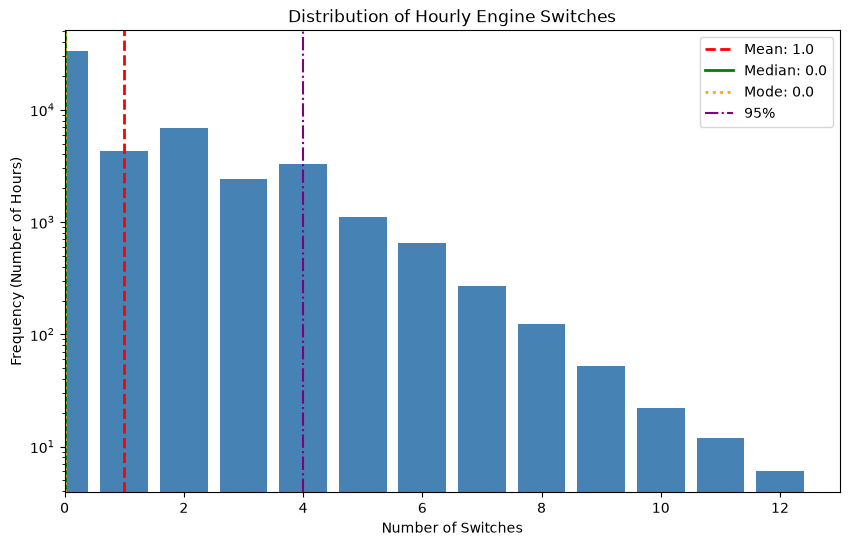

In [14]:
import matplotlib.pyplot as plt

# Delete the dataframes and large variables

# 1. Set up the figure size
plt.figure(figsize=(10, 6))

# 2. Plot using matplotlib directly to keep the x-axis numeric
# If your bins are groups of 5, set width to something like 4 or 4.5 so they don't overlap
plt.bar(
    pdf['switch_bin'], 
    pdf['count'], 
    color='steelblue', 
    width=0.8
)

# 3. Add the vertical lines (axvline)
# Mean, Median, and Mode
plt.axvline(x=mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.1f}')
plt.axvline(x=median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.1f}')
plt.axvline(x=mode_val, color='orange', linestyle=':', linewidth=2, label=f'Mode: {mode_val:.1f}')

# 95% percentile
plt.axvline(x=p95, color='purple', linestyle='-.', linewidth=1.5, label='95%')


# 4. Add labels and display
plt.title('Distribution of Hourly Engine Switches')
plt.xlabel('Number of Switches')
plt.ylabel('Frequency (Number of Hours)')
plt.yscale("log")
plt.xlim([0, 13])
plt.legend() # This displays the labels we defined in the axvline functions
plt.show()

# Closes all background figures and releases their memory
plt.close('all')

In [15]:
spark.stop()

## Second part of anomaly detection 1

In [6]:
# Begin from the correct df: df_aggregated

import pyspark.sql.functions as F

# I define again the hour bucket in order to count the switches
df_anomaly1 = df_aggregated.withColumn(
    "hour_bucket", 
    F.date_trunc("hour", F.col("timestamp_bucket"))
)

df_anomaly1.printSchema()


root
 |-- timestamp_bucket: timestamp (nullable = true)
 |-- hwid: string (nullable = true)
 |-- metric: string (nullable = true)
 |-- aggregated_value: double (nullable = true)
 |-- hour_bucket: timestamp (nullable = true)



In [7]:
from pyspark.sql.types import IntegerType

# 1. Group by the hour, device, and metric to break the data into tiny chunks
# We collect the timestamp and value into a mini-table (struct) inside a list
df_grouped = df_anomaly1.groupBy("hour_bucket", "hwid", "metric").agg(
    F.collect_list(
        F.struct("timestamp_bucket", "aggregated_value")
    ).alias("time_series")
)

# 2. Sort the 60-minute array chronologically (this happens instantly in memory)
df_sorted = df_grouped.withColumn(
    "time_series_sorted", 
    F.array_sort("time_series")
)

# 3. Create a simple Python function (UDF) to count the switches in that small list
def count_switches(time_series):
    if not time_series or len(time_series) < 2:
        return 0
    switches = 0
    # Iterate through the minutes in the hour
    for i in range(1, len(time_series)):
        # Compare current minute's value to the previous minute's value
        if time_series[i].aggregated_value != time_series[i-1].aggregated_value:
            switches += 1
    return switches

# Register the Python function as a PySpark UDF
count_switches_udf = F.udf(count_switches, IntegerType())

# 4. Apply the function to get the final count!
target_metrics = ["S117", "S118", "S169", "S170"]

df_hourly_frequency = df_sorted.withColumn(
    "total_state_switches", 
    F.when(
        F.col("metric").isin(target_metrics), 
        count_switches_udf(F.col("time_series_sorted"))
    ).otherwise(F.lit(None))
).drop("time_series_sorted") # Clean up the temporary columns

df_hourly_frequency.printSchema()

root
 |-- hour_bucket: timestamp (nullable = true)
 |-- hwid: string (nullable = true)
 |-- metric: string (nullable = true)
 |-- time_series: array (nullable = false)
 |    |-- element: struct (containsNull = false)
 |    |    |-- timestamp_bucket: timestamp (nullable = true)
 |    |    |-- aggregated_value: double (nullable = true)
 |-- total_state_switches: integer (nullable = true)



In [8]:
# Define the threshold from the previous section

thr = 4 # For now it is only a guess

df_anomalies = df_hourly_frequency.where(
    F.col("total_state_switches") > thr
)

df_exploded = df_anomalies.withColumn(
    "single_record", 
    F.explode("time_series")
)

# Extract the struct fields and clean up
df_reconstructed = df_exploded.withColumn(
    "timestamp_bucket", 
    F.col("single_record.timestamp_bucket")
).withColumn(
    "aggregated_value", 
    F.col("single_record.aggregated_value")
).drop(
    "time_series",           # Drop the original list
    "single_record",         # Drop the temporary struct column
    "total_state_switches"   # Drop the anomaly count (as requested)
)

df_reconstructed.printSchema()

root
 |-- hour_bucket: timestamp (nullable = true)
 |-- hwid: string (nullable = true)
 |-- metric: string (nullable = true)
 |-- timestamp_bucket: timestamp (nullable = true)
 |-- aggregated_value: double (nullable = true)



## Correlation analysis: engine switch frequency vs. other metrics

**Goal (Section 3.3.1 – Correlation Analysis):** Identify possible correlations
between the higher frequency of engine ON/OFF events and other variables in the dataset.

**Design choices:**
1. Each engine (S117, S118, S169, S170) is correlated **separately** — mixing them would be physically meaningless.
2. The sensor metrics are split into **small thematic groups** so only one group is pivoted at a time, keeping RAM under control.
3. Everything runs inside **Spark**: a single pivot + join + agg, collected once.
4. A **heatmap** is drawn at the end for a quick visual summary.

In [ ]:
# ── Metric groups (small lists to keep RAM usage low) ──────────────────────
# Pick ONE group at a time by setting SELECTED_GROUP in the next cell.
# Each group contains physically related metrics so correlations are meaningful.

metric_groups = {
    # ── Temperatures ──
    "temperatures": {
        "S41":  "External Temp",
        "S39":  "Utility Water IN",
        "S40":  "Utility Water OUT",
        "S49":  "Source Water IN",
        "S50":  "Source Water OUT",
        "S45":  "Free-Cool Water Temp",
        "S46":  "Recovery Water IN",
        "S47":  "Recovery Water OUT",
    },
    # ── Pressures ──
    "pressures": {
        "S100": "Suction Press Cool C1",
        "S101": "Suction Press Heat C1",
        "S102": "Discharge Press C1",
        "S157": "Suction Press Cool C2",
        "S158": "Suction Press Heat C2",
        "S159": "Discharge Press C2",
    },
    # ── Capacities & loading ──
    "capacities": {
        "S125": "Capacity Circ 1",
        "S181": "Capacity Circ 2",
        "S126": "Pressure Ratio C1",
        "S43":  "Demand Limit",
    },
    # ── Discharge & circuit temperatures ──
    "discharge_temps": {
        "S109": "Discharge Temp C1,1",
        "S110": "Discharge Temp C2,1",
        "S165": "Discharge Temp C1,2",
        "S166": "Discharge Temp C2,2",
        "S106": "Source Inlet Temp C1",
        "S107": "Liquid Temp C1",
        "S108": "Source Temp OUT C1",
        "S163": "Source Temp IN C2",
        "S164": "Liquid Temp C2",
    },
    # ── Superheat & EEV ──
    "superheat_eev": {
        "S81":  "SH PID1 C1",
        "S83":  "SH PID2 C1",
        "S86":  "EEV Pos PID2 C1",
        "S90":  "EEV Pos PID1 C1",
        "S138": "SH PID1 C2",
        "S140": "SH PID2 C2",
        "S143": "SH circ2 PID3",
    },
    # ── Inverter & valve signals ──
    "signals_valves": {
        "S19":  "Source Inverter",
        "S37":  "Utility Inverter",
        "S69":  "Free-Cool Valve Sig",
        "S70":  "Recovery Pump Sig",
        "S122": "Sig Inv Fan C1",
        "S178": "Sig Inv Fan C2",
        "S42":  "Water Reset",
    },
    """
    # ── Power & energy ──
    "power_energy": {
        "E1":   "Active Power",
        "E2":   "Reactive Power",
    },
    """
    # ── Subcooling & misc ──
    "subcooling_misc": {
        "S124": "Subcooling C1",
        "S180": "Subcooling C2",
        "S94":  "EEV Pos PID3 C1",
        "S97":  "SH PID3 C1",
        "S128": "Chiller Valve C1",
        "S129": "Recovery Valve C1",
        "S147": "Defrost Mode C1",
        "S151": "C1 Mode",
        "S154": "Set-Point SH PID1 C2",
    },
}

print("Available metric groups:")
for name, metrics in metric_groups.items():
    print(f"  \u2022 {name:20s}  ({len(metrics)} metrics: {', '.join(metrics.keys())})")


Available metric groups:
  • temperatures          (8 metrics: S41, S39, S40, S49, S50, S45, S46, S47)
  • pressures             (6 metrics: S100, S101, S102, S157, S158, S159)
  • capacities            (4 metrics: S125, S181, S126, S43)
  • discharge_temps       (9 metrics: S109, S110, S165, S166, S106, S107, S108, S163, S164)
  • superheat_eev         (7 metrics: S81, S83, S86, S90, S138, S140, S143)
  • signals_valves        (7 metrics: S19, S37, S69, S70, S122, S178, S42)
  • power_energy          (2 metrics: E1, E2)
  • subcooling_misc       (9 metrics: S124, S180, S94, S97, S128, S129, S147, S151, S154)


In [10]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  SELECT THE GROUP TO CORRELATE  (change this variable)         ║
# ╚══════════════════════════════════════════════════════════════════╝

SELECTED_GROUP = "temperatures"   # <── change me to any key from metric_groups


In [11]:
import pyspark.sql.functions as F

# ── Engine metrics (one per compressor) ──────────────────────────────────
engine_codes = ["S117", "S118", "S169", "S170"]
engine_labels = {
    "S117": "Status Comp 1,1",
    "S118": "Status Comp 2,1",
    "S169": "Status Comp 1,2",
    "S170": "Status Comp 2,2",
}

# ── Retrieve the selected sensor group ──────────────────────────────────
selected_metrics = metric_groups[SELECTED_GROUP]        # dict {code: label}
sensor_codes     = list(selected_metrics.keys())

print(f"Correlating each engine against group '{SELECTED_GROUP}':")
print(f"  Sensors: {sensor_codes}\n")

# ── 1. Pivot the engine switches: one column per engine ─────────────────
# From df_hourly_frequency we only keep the engine rows and pivot them
# so each engine becomes its own column of switch counts.
df_engine_wide = (
    df_hourly_frequency
    .filter(F.col("metric").isin(engine_codes))
    .groupBy("hour_bucket", "hwid")
    .pivot("metric", engine_codes)      # restrict pivot values
    .agg(F.first("total_state_switches"))
)

df_engine_wide.printSchema()


Correlating each engine against group 'temperatures':
  Sensors: ['S41', 'S39', 'S40', 'S49', 'S50', 'S45', 'S46', 'S47']

root
 |-- hour_bucket: timestamp (nullable = true)
 |-- hwid: string (nullable = true)
 |-- S117: integer (nullable = true)
 |-- S118: integer (nullable = true)
 |-- S169: integer (nullable = true)
 |-- S170: integer (nullable = true)



In [12]:
# ── 2. Pivot the selected sensors: one column per sensor ───────────────
# From df_anomaly1 (= df_aggregated + hour_bucket) we filter only the
# selected sensor group and average their values per hour.
df_sensors_wide = (
    df_anomaly1
    .filter(F.col("metric").isin(sensor_codes))
    .groupBy("hour_bucket", "hwid")
    .pivot("metric", sensor_codes)       # restrict pivot values
    .agg(F.avg("aggregated_value"))
)

# ── 3. Join engine switches with sensor values ─────────────────────────
# Single join — Spark handles the shuffle internally.
df_joined = df_engine_wide.join(
    df_sensors_wide,
    on=["hour_bucket", "hwid"],
    how="inner"
)

df_joined.printSchema()


root
 |-- hour_bucket: timestamp (nullable = true)
 |-- hwid: string (nullable = true)
 |-- S117: integer (nullable = true)
 |-- S118: integer (nullable = true)
 |-- S169: integer (nullable = true)
 |-- S170: integer (nullable = true)
 |-- S41: double (nullable = true)
 |-- S39: double (nullable = true)
 |-- S40: double (nullable = true)
 |-- S49: double (nullable = true)
 |-- S50: double (nullable = true)
 |-- S45: double (nullable = true)
 |-- S46: double (nullable = true)
 |-- S47: double (nullable = true)



In [13]:
# ── 4. Build ALL correlation expressions ──────────────────────────────
# For each (engine, sensor) pair we compute Pearson r, per device.
# This is a SINGLE groupBy().agg() call — no Python loops over Spark.

corr_exprs = []
for eng in engine_codes:
    for s in sensor_codes:
        alias = f"corr_{eng}_vs_{s}"
        corr_exprs.append(F.corr(eng, s).alias(alias))

df_correlation = df_joined.groupBy("hwid").agg(*corr_exprs)

df_correlation.printSchema()
df_correlation.show(truncate=False)


root
 |-- hwid: string (nullable = true)
 |-- corr_S117_vs_S41: double (nullable = true)
 |-- corr_S117_vs_S39: double (nullable = true)
 |-- corr_S117_vs_S40: double (nullable = true)
 |-- corr_S117_vs_S49: double (nullable = true)
 |-- corr_S117_vs_S50: double (nullable = true)
 |-- corr_S117_vs_S45: double (nullable = true)
 |-- corr_S117_vs_S46: double (nullable = true)
 |-- corr_S117_vs_S47: double (nullable = true)
 |-- corr_S118_vs_S41: double (nullable = true)
 |-- corr_S118_vs_S39: double (nullable = true)
 |-- corr_S118_vs_S40: double (nullable = true)
 |-- corr_S118_vs_S49: double (nullable = true)
 |-- corr_S118_vs_S50: double (nullable = true)
 |-- corr_S118_vs_S45: double (nullable = true)
 |-- corr_S118_vs_S46: double (nullable = true)
 |-- corr_S118_vs_S47: double (nullable = true)
 |-- corr_S169_vs_S41: double (nullable = true)
 |-- corr_S169_vs_S39: double (nullable = true)
 |-- corr_S169_vs_S40: double (nullable = true)
 |-- corr_S169_vs_S49: double (nullable = true)

26/09/09 14:49:01 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
26/09/09 14:49:38 WARN TaskSetManager: Lost task 0.0 in stage 30.0 (TID 42) (10.67.22.69 executor 0): org.apache.spark.SparkArithmeticException: [DIVIDE_BY_ZERO] Division by zero. Use `try_divide` to tolerate divisor being 0 and return NULL instead. If necessary set "spark.sql.ansi.enabled" to "false" to bypass this error. SQLSTATE: 22012
== DataFrame ==
"corr" was called from
java.base/jdk.internal.reflect.NativeMethodAccessorImpl.invoke0(Native Method)

	at org.apache.spark.sql.errors.QueryExecutionErrors$.divideByZeroError(QueryExecutionErrors.scala:205)
	at org.apache.spark.sql.errors.QueryExecutionErrors.divideByZeroError(QueryExecutionErrors.scala)
	at org.apache.spark.sql.catalyst.expressions.GeneratedClass$SpecificMutableProjection.If_3$(Unknown Source)
	at org.apache.spark.sql.catalyst.expre

ArithmeticException: [DIVIDE_BY_ZERO] Division by zero. Use `try_divide` to tolerate divisor being 0 and return NULL instead. If necessary set "spark.sql.ansi.enabled" to "false" to bypass this error. SQLSTATE: 22012
== DataFrame ==
"corr" was called from
java.base/jdk.internal.reflect.NativeMethodAccessorImpl.invoke0(Native Method)


In [ ]:
import pandas as pd
import numpy as np

# ── 5. Collect the small result to Pandas (only #devices rows) ─────────
pdf_corr = df_correlation.toPandas()
pdf_corr


In [ ]:
import matplotlib.pyplot as plt
import matplotlib

# ── 6. Build (engines × sensors) heatmap, averaged across devices ──────

# Reshape the flat correlation columns into a 2D matrix
rows = []
for eng in engine_codes:
    row = {}
    for s in sensor_codes:
        col_name = f"corr_{eng}_vs_{s}"
        row[selected_metrics[s]] = pdf_corr[col_name].mean()   # mean across devices
    rows.append(row)

pdf_heatmap = pd.DataFrame(rows, index=[engine_labels[e] for e in engine_codes])

# ── Plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(max(8, len(sensor_codes) * 1.5), 5))

data = pdf_heatmap.values.astype(float)
cmap = plt.cm.RdBu_r   # diverging: blue = negative, red = positive
norm = matplotlib.colors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

im = ax.imshow(data, cmap=cmap, norm=norm, aspect="auto")

# Axes labels
ax.set_xticks(range(len(pdf_heatmap.columns)))
ax.set_xticklabels(pdf_heatmap.columns, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(pdf_heatmap.index)))
ax.set_yticklabels(pdf_heatmap.index, fontsize=10)

# Annotate each cell with the correlation value
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        val = data[i, j]
        if np.isnan(val):
            txt = "n/a"
        else:
            txt = f"{val:.2f}"
        text_color = "white" if abs(val if not np.isnan(val) else 0) > 0.55 else "black"
        ax.text(j, i, txt, ha="center", va="center",
                fontsize=9, color=text_color, fontweight="bold")

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label("Pearson r", fontsize=10)

ax.set_title(
    f"Correlation: engine switch frequency vs '{SELECTED_GROUP}' metrics\n"
    f"(averaged across devices)",
    fontsize=12, fontweight="bold"
)

plt.tight_layout()
plt.show()
plt.close("all")


In [ ]:
# ── Optional: per-device heatmap for a single engine ──────────────────
# Useful to see whether different devices show different patterns.

ENGINE_TO_PLOT = "S117"   # <── change to S118, S169, or S170 if needed

# Extract only the columns for this engine
eng_corr_cols = [f"corr_{ENGINE_TO_PLOT}_vs_{s}" for s in sensor_codes]

pdf_eng = pdf_corr[["hwid"] + eng_corr_cols].copy()
pdf_eng = pdf_eng.set_index("hwid")
pdf_eng.columns = [selected_metrics[s] for s in sensor_codes]  # human-readable

fig, ax = plt.subplots(figsize=(max(8, len(sensor_codes) * 1.5), max(4, len(pdf_eng) * 0.8)))

data = pdf_eng.values.astype(float)
im = ax.imshow(data, cmap=cmap, norm=norm, aspect="auto")

ax.set_xticks(range(len(pdf_eng.columns)))
ax.set_xticklabels(pdf_eng.columns, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(pdf_eng.index)))
ax.set_yticklabels(pdf_eng.index, fontsize=10)

for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        val = data[i, j]
        if np.isnan(val):
            txt = "n/a"
        else:
            txt = f"{val:.2f}"
        text_color = "white" if abs(val if not np.isnan(val) else 0) > 0.55 else "black"
        ax.text(j, i, txt, ha="center", va="center",
                fontsize=9, color=text_color, fontweight="bold")

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label("Pearson r", fontsize=10)

ax.set_title(
    f"Per-device correlations for engine {ENGINE_TO_PLOT} "
    f"({engine_labels[ENGINE_TO_PLOT]})\n"
    f"vs '{SELECTED_GROUP}' metrics",
    fontsize=12, fontweight="bold"
)

plt.tight_layout()
plt.show()
plt.close("all")


In [ ]:
spark.stop()
